In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools as it
import statistics as stat
import json
#from wpb_tools import *

In [2]:
# angle bounds for determining cis vs trans configurations

cislower = -90
cisupper = 50
translower = 100
transupper = 240

# NOTE: This variable was originally created for looking at the unreweighted data, but was abandoned
# partway through the notebook to focus on the reweighted data
has_weights = 1 # 0 = no, unreweighted data; 1 = yes, reweighted data

nsim = 10 # number of simulations

In [3]:
params = [{'sep':r'\s+', 'low_memory':False}, {'engine':'c'}][0]

ctd_secstruc = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/analysis/turn/ctd_sec.out', **params)
ctd_phos_secstruc = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/analysis/turn/ctd_p_sec.out', **params)

In [4]:
ctd_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/analysis/turn/ctd_dihedral_Omega.dat', sep = r'\s+')
ctd_phos_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/analysis/turn/ctd_dihedral_Omega.dat', sep = r'\s+')

In [5]:
# Weights (unphos)

if has_weights ==1:
    ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)
    p_ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [6]:
if has_weights == 1:
    ctd_weights_combined = ctd_weights_combined_raw/ctd_weights_combined_raw.sum()
    p_ctd_weights_combined = p_ctd_weights_combined_raw/p_ctd_weights_combined_raw.sum()

In [7]:
# function for computing means and sems of datasets

def turn_plot_mean_sem(has_weights, data, nsim): # (INCLUDE DATA TYPES)Weighted: yes, reweighted = 1, no, not reweighted = 0, data = dataset, nsim = # of simulations
    # if reweighted
    if has_weights == 1:
        dfs = np.array_split(data, nsim)
        sums = [part.sum() for part in dfs]
        sum_df = pd.DataFrame(sums, index=[f'sim{i}' for i in range(nsim)])*nsim
        # Calculate the mean and standard deviation for each DataFrame in 'dfs'
        means = sum_df.mean()
        sems = sum_df.sem()
        ctd = sum_df
        
    # if not reweighted
    else:
        dfs = np.array_split(data, nsim) 
        sums = [part.mean() for part in dfs]
        sum_df = pd.DataFrame(sums, index=[f'sim{i}' for i in range(nsim)])
        # Calculate the mean and standard deviation for each DataFrame in 'dfs'
        means = sum_df.mean()
        sems = sum_df.sem()
        # Add the mean and std deviation as new rows in the sum_df DataFrame
        sum_df.loc['mean'] = means
        sum_df.loc['sem'] = sems
        ctd = sum_df
    
    return sum_df

In [8]:
if has_weights == 1:
    # Make sure both DataFrames and Series are aligned
    p_frame_col = ctd_phos_secstruc["#Frame"].reset_index(drop=True)
    ctd_phos_secstruc_reweighted = (
        (ctd_phos_secstruc.drop(columns="#Frame") == "T")
        .mul(p_ctd_weights_combined[0].values, axis=0)
        .reset_index(drop=True)
    )
    # Insert frame column
    ctd_phos_secstruc_reweighted["#Frame"] = p_frame_col
else:
    ctd_phos_inturn = ctd_phos_secstruc == "T"

In [9]:
if has_weights == 1:
    # Make sure both DataFrames and Series are aligned
    frame_col = ctd_secstruc["#Frame"].reset_index(drop=True)
    ctd_secstruc_reweighted = (
        (ctd_secstruc.drop(columns="#Frame") == "T")
        .mul(ctd_weights_combined[0].values, axis=0)
        .reset_index(drop=True)
    )
    # Insert frame column
    ctd_secstruc_reweighted["#Frame"] = frame_col
else:
    ctd_inturn = ctd_secstruc == "T"

In [10]:
# compute means and sems

if has_weights == 1:
    ctd = turn_plot_mean_sem(has_weights, ctd_secstruc_reweighted, nsim)
    ctd_phos = turn_plot_mean_sem(has_weights, ctd_phos_secstruc_reweighted, nsim)
else:    
    ctd = turn_plot_mean_sem(has_weights, ctd_inturn, nsim)
    ctd_phos = turn_plot_mean_sem(has_weights, ctd_phos_inturn, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [11]:
secstruc_weights_list = np.array_split(ctd_secstruc_reweighted, nsim)

In [14]:
secstruc_weights = pd.DataFrame(np.nan, index=ctd.index, columns=ctd.columns)

In [15]:
i = 0
for sim in secstruc_weights_list:
    #print(sim.sum())
    secstruc_weights.iloc[i,:] = sim.sum()
    i += 1

In [16]:
secstruc_weights.iloc[:-2,0] = 1
secstruc_weights.iloc[:-2,-3:] = 1

In [17]:
secstruc_weights

,ACE:1,TYR:2,SER:3,PRO:4,THR:5,SER:6,PRO:7,SER:8,TYR:9,SER:10,...,SER:15,TYR:16,SER:17,PRO:18,THR:19,SER:20,PRO:21,SER:22,NHE:23,#Frame
sim0,1.0,0.000910,0.006530,0.013871,0.012425,0.006178,0.023348,0.026076,0.014845,0.004061,...,0.024691,0.016525,0.012418,0.019781,0.015126,0.004213,0.004218,1.0,1.0,1.000000e+00
sim1,1.0,0.000657,0.005200,0.015164,0.014584,0.009824,0.021276,0.020358,0.010882,0.009203,...,0.028695,0.016248,0.007947,0.017158,0.015225,0.005724,0.005636,1.0,1.0,1.000000e+00
sim2,1.0,0.000984,0.006087,0.022244,0.020548,0.011152,0.025394,0.027570,0.016354,0.007279,...,0.027571,0.015997,0.005714,0.015638,0.013936,0.005013,0.005015,1.0,1.0,1.000000e+00
sim3,1.0,0.000811,0.004156,0.016134,0.014990,0.006264,0.019264,0.023114,0.015184,0.004267,...,0.026056,0.014981,0.008118,0.019935,0.017333,0.004644,0.004655,1.0,1.0,1.000000e+00
sim4,1.0,0.000989,0.008463,0.016912,0.014696,0.007698,0.022800,0.026901,0.015533,0.010016,...,0.028411,0.014731,0.007391,0.017552,0.014200,0.004144,0.004132,1.0,1.0,1.000000e+00
sim5,1.0,0.000532,0.005679,0.012732,0.011559,0.004907,0.016125,0.020062,0.013693,0.005755,...,0.017092,0.011316,0.005567,0.011269,0.009241,0.003128,0.003101,1.0,1.0,1.000000e+00
sim6,1.0,0.000497,0.002468,0.009502,0.009044,0.004056,0.012311,0.014059,0.009022,0.004686,...,0.020457,0.013228,0.005953,0.010382,0.008268,0.001974,0.002007,1.0,1.0,1.000000e+00
sim7,1.0,0.000691,0.003779,0.012630,0.012081,0.005293,0.015769,0.018821,0.013033,0.007714,...,0.016636,0.007679,0.004573,0.012048,0.010337,0.003213,0.003109,1.0,1.0,1.000000e+00
sim8,0.0,0.000602,0.004105,0.012997,0.011712,0.005265,0.013831,0.016673,0.011165,0.007142,...,0.017665,0.009780,0.005242,0.012029,0.010811,0.004353,0.004366,0.0,0.0,1.958400e+14
sim9,0.0,0.000601,0.004673,0.010901,0.009768,0.004643,0.020967,0.023889,0.013896,0.003509,...,0.013430,0.007121,0.004698,0.010320,0.008890,0.003464,0.003476,0.0,0.0,2.188800e+14


In [18]:
def weighted_mean_and_se(values, weights):
    """
    Calculates the weighted mean and its standard error.

    Args:
        values (array-like): The data values.
        weights (array-like): The corresponding weights for each value.

    Returns:
        tuple: A tuple containing the weighted mean and the standard error of the weighted mean.
    """
    values = np.array(values)
    weights = np.array(weights)

    if len(values) != len(weights):
        raise ValueError("Values and weights must have the same length.")

    # Create a boolean mask to find non-NaN values in both data and weights.
    valid_mask = ~np.isnan(values) & ~np.isnan(weights)
    
    # Filter the data and weights to keep only valid entries.
    valid_data = values[valid_mask]
    valid_weights = weights[valid_mask]

    # Calculate the weighted mean
    weighted_mean = np.average(valid_data, weights=valid_weights)

    # Calculate the weighted variance
    # For sample variance, adjust for degrees of freedom (n-1)
    # The denominator for weighted variance is typically sum(weights) - (sum(weights^2) / sum(weights))
    # or a simpler form for large samples. Here we use a common form for sample weighted variance.
    sum_of_weights = np.sum(valid_weights)
    weighted_variance = np.sum(valid_weights * (valid_data - weighted_mean)**2) / (sum_of_weights - (np.sum(valid_weights**2) / sum_of_weights))

    # Calculate the standard error of the weighted mean
    # SE = sqrt(weighted_variance / effective_sample_size)
    # Effective sample size can be considered as (sum_of_weights)^2 / sum(weights^2)
    effective_sample_size = (sum_of_weights**2) / np.sum(valid_weights**2)
    standard_error = np.sqrt(weighted_variance / effective_sample_size)

    return weighted_mean, standard_error

In [19]:
mean_list = []
sem_list = []
for i in range(len(ctd.columns)):
    #print(i)
    mean_list.append(weighted_mean_and_se(ctd.iloc[:,i].tolist(), secstruc_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(ctd.iloc[:,i].tolist(), secstruc_weights.iloc[:,i].tolist())[1])

In [20]:
mean_list

[0.0,
 0.00769236967677507,
 0.0561096402943696,
 0.15117473100037163,
 0.13879903372460511,
 0.07281711573891886,
 0.2001589197084768,
 0.22597507337100287,
 0.1373106184894204,
 0.07081362890909809,
 0.17100204093815838,
 0.14904793385030274,
 0.08764444275371208,
 0.21373651641894956,
 0.23375565818899827,
 0.13657496469685879,
 0.07504167137237709,
 0.15514305299150383,
 0.1307796948066807,
 0.04247279552777345,
 0.04227585600387511,
 0.0,
 0.0,
 2080000023925903.8]

In [21]:
df_with_mean = pd.concat([ctd, pd.DataFrame([mean_list], index=['mean'], columns=ctd.columns)])
ctd = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=ctd.columns)])

In [22]:
ctd

,ACE:1,TYR:2,SER:3,PRO:4,THR:5,SER:6,PRO:7,SER:8,TYR:9,SER:10,...,SER:15,TYR:16,SER:17,PRO:18,THR:19,SER:20,PRO:21,SER:22,NHE:23,#Frame
sim0,0.0,0.009104,0.065301,0.138713,0.124250,0.061783,0.233478,0.260762,0.148447,0.040613,...,0.246908,0.165247,0.124183,0.197806,0.151258,0.042134,0.042178,0.0,0.0,1.152000e+14
sim1,0.0,0.006570,0.051998,0.151643,0.145841,0.098236,0.212762,0.203584,0.108815,0.092028,...,0.286951,0.162482,0.079466,0.171580,0.152252,0.057244,0.056356,0.0,0.0,3.456000e+14
sim2,0.0,0.009837,0.060871,0.222437,0.205485,0.111515,0.253940,0.275701,0.163537,0.072789,...,0.275706,0.159971,0.057142,0.156382,0.139356,0.050128,0.050146,0.0,0.0,5.760000e+14
sim3,0.0,0.008109,0.041558,0.161338,0.149901,0.062638,0.192641,0.231143,0.151836,0.042673,...,0.260556,0.149815,0.081184,0.199346,0.173331,0.046438,0.046547,0.0,0.0,8.064000e+14
sim4,0.0,0.009892,0.084634,0.169118,0.146958,0.076978,0.227995,0.269005,0.155334,0.100158,...,0.284108,0.147312,0.073905,0.175523,0.141999,0.041443,0.041320,0.0,0.0,1.036800e+15
sim5,0.0,0.005325,0.056794,0.127318,0.115587,0.049071,0.161250,0.200617,0.136928,0.057552,...,0.170924,0.113162,0.055674,0.112694,0.092410,0.031278,0.031010,0.0,0.0,1.267200e+15
sim6,0.0,0.004974,0.024683,0.095018,0.090436,0.040561,0.123105,0.140588,0.090219,0.046864,...,0.204569,0.132282,0.059532,0.103824,0.082678,0.019745,0.020070,0.0,0.0,1.497600e+15
sim7,0.0,0.006911,0.037793,0.126298,0.120813,0.052928,0.157693,0.188205,0.130328,0.077136,...,0.166356,0.076786,0.045733,0.120475,0.103369,0.032128,0.031095,0.0,0.0,1.728000e+15
sim8,0.0,0.006022,0.041049,0.129970,0.117118,0.052646,0.138307,0.166733,0.111652,0.071424,...,0.176655,0.097798,0.052424,0.120289,0.108109,0.043532,0.043663,0.0,0.0,1.958400e+15
sim9,0.0,0.006007,0.046731,0.109007,0.097680,0.046426,0.209672,0.238891,0.138959,0.035088,...,0.134304,0.071211,0.046982,0.103196,0.088897,0.034642,0.034759,0.0,0.0,2.188800e+15


In [23]:
phos_secstruc_weights_list = np.array_split(ctd_phos_secstruc_reweighted, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [24]:
phos_secstruc_weights = pd.DataFrame(np.nan, index=ctd_phos.index, columns=ctd_phos.columns)

In [25]:
i = 0
for sim in phos_secstruc_weights_list:
    #print(sim.sum())
    phos_secstruc_weights.iloc[i,:] = sim.sum()
    i += 1

In [26]:
phos_secstruc_weights.iloc[:-2,0] = 1
phos_secstruc_weights.iloc[:-2,-3:] = 1

In [27]:
mean_list = []
sem_list = []
for i in range(len(ctd_phos.columns)):
    #print(i)
    mean_list.append(weighted_mean_and_se(ctd_phos.iloc[:,i].tolist(), phos_secstruc_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(ctd_phos.iloc[:,i].tolist(), phos_secstruc_weights.iloc[:,i].tolist())[1])

In [28]:
df_with_mean = pd.concat([ctd_phos, pd.DataFrame([mean_list], index=['mean'], columns=ctd_phos.columns)])
ctd_phos = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=ctd_phos.columns)])

In [30]:
whole_ctd = ctd.loc[['mean']].iloc[:,1:22]
whole_ctd_p = ctd_phos.loc[['mean']].iloc[:,1:22]
whole_ctd_sem = ctd.loc[['sem']].iloc[:,1:22]
whole_ctd_p_sem = ctd_phos.loc[['sem']].iloc[:,1:22]

In [31]:
mid_ctd = whole_ctd.iloc[:,7:14]
mid_ctd_p = whole_ctd_p.iloc[:,7:14]
mid_ctd_sem = whole_ctd_sem.iloc[:,7:14]
mid_ctd_p_sem = whole_ctd_p_sem.iloc[:,7:14]

In [32]:
# Check the mean percentage of turn across all residues
whole_ctd.mean(axis = 1)

mean    0.118968
dtype: float64

In [33]:
whole_ctd_p.mean(axis = 1)

mean    0.256867
dtype: float64

In [34]:
mid_ctd

,TYR:9,SER:10,PRO:11,THR:12,SER:13,PRO:14,SER:15
mean,0.137311,0.070814,0.171002,0.149048,0.087644,0.213737,0.233756


In [35]:
mid_ctd_sem

,TYR:9,SER:10,PRO:11,THR:12,SER:13,PRO:14,SER:15
sem,0.007064,0.007472,0.009356,0.00756,0.011889,0.017215,0.017578


In [36]:
mid_ctd_p

,TYR:9,SER:10,PRO:11,THR:12,SEP:13,PRO:14,SER:15
mean,0.293956,0.069094,0.12258,0.119775,0.270032,0.528034,0.45742


In [37]:
mid_ctd_p_sem

,TYR:9,SER:10,PRO:11,THR:12,SEP:13,PRO:14,SER:15
sem,0.056923,0.010911,0.0316,0.014696,0.03774,0.060966,0.052507


Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


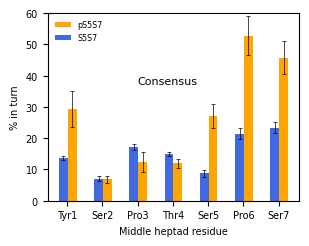

In [119]:
plt.figure()
x = ["Tyr1","Ser2","Pro3","Thr4","Ser5","Pro6","Ser7"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, mid_ctd_p.iloc[0]*100, 0.25, yerr = mid_ctd_p_sem.iloc[0]*100,  error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, label='pS5S7', color='orange')
plt.bar(x_axis - 0.11, mid_ctd.iloc[0]*100, 0.25, yerr = mid_ctd_sem.iloc[0]*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, label='S5S7', color='royalblue')
#yerr=np.array(list(unphos_std.values()))*100
plt.xticks(x_axis, x, fontsize = 7)
plt.yticks(fontsize = 7)
plt.legend(loc = "upper left", fontsize = 5.75, frameon=False)
plt.ylabel("% in turn", fontsize = 7)
plt.xlabel("Middle heptad residue", fontsize = 7)
plt.text(2, 40, 'Consensus', fontsize=8, verticalalignment='top')
plt.ylim(top=60)  
plt.ylim(bottom=0)
#plt.title("CTD Turn Character")

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('con_turn_3.25in.png', dpi=300, bbox_inches='tight')

plt.show()

In [43]:
df_360 = ctd_omega_angles_raw.copy()
# loop through columns to convert numbers below -90
for col in df_360:
    df_360.loc[df_360[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360[col] = round(df_360[col])  # Round angles to the nearest integer

In [44]:
df_360.head()

,#Frame,omega:3,omega:4,omega:5,omega:6,omega:7,omega:8,omega:9,omega:10,omega:11,...,omega:13,omega:14,omega:15,omega:16,omega:17,omega:18,omega:19,omega:20,omega:21,omega:22
0,1,169.0,170.0,159.0,177.0,152.0,203.0,168.0,176.0,179.0,...,181.0,-18.0,166.0,171.0,147.0,219.0,182.0,210.0,-76.0,202.0
1,2,170.0,170.0,161.0,181.0,152.0,197.0,144.0,185.0,177.0,...,184.0,-6.0,173.0,186.0,160.0,229.0,189.0,214.0,-43.0,182.0
2,3,161.0,164.0,155.0,162.0,165.0,212.0,151.0,195.0,184.0,...,194.0,-2.0,168.0,161.0,145.0,235.0,192.0,226.0,-29.0,177.0
3,4,166.0,160.0,153.0,183.0,156.0,206.0,142.0,188.0,182.0,...,201.0,-9.0,166.0,176.0,134.0,220.0,180.0,221.0,-43.0,209.0
4,5,169.0,167.0,147.0,170.0,172.0,195.0,150.0,199.0,184.0,...,186.0,0.0,161.0,176.0,153.0,231.0,182.0,214.0,-41.0,198.0


In [45]:
df_360_phos = ctd_phos_omega_angles_raw # Create a new column to hold the 360-degree adjusted omega values
# loop through columns to convert numbers below -90
for col in df_360_phos:
    df_360_phos.loc[df_360_phos[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360_phos[col] = round(df_360_phos[col])  # Round angles to the nearest integer

In [46]:
# retaining omega angle values
ctd_phos_omega_angles = df_360_phos.copy()
ctd_omega_angles = df_360.copy()

In [47]:
# labelling configurationgs of omega angles
temp_angles = ctd_phos_omega_angles.copy()

ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_phos_omega_angles[(ctd_phos_omega_angles.iloc[:,1:] != "cis") & (ctd_phos_omega_angles.iloc[:,1:] != "trans")] = "neither"

temp_angles = ctd_omega_angles.copy()

ctd_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_omega_angles[(ctd_omega_angles.iloc[:,1:] != "cis") & (ctd_omega_angles.iloc[:,1:] != "trans")] = "neither"

/tmp/ipykernel_2216912/3590104210.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
/tmp/ipykernel_2216912/3590104210.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"


In [48]:
ctd_omega_angles['weights'] = ctd_weights_combined[0]

In [49]:
ctd_phos_omega_angles['weights'] = p_ctd_weights_combined[0]

# Unphosphorylated

In [50]:
ctd_secstruc = ctd_secstruc.reset_index(drop=True)
ctd_secstruc_cistrans = ctd_secstruc.copy()
ctd_secstruc_cistrans['cis/trans/neither'] = ctd_omega_angles['omega:14']
ctd_secstruc_cistrans['weights'] = ctd_weights_combined[0]

In [51]:
# Split dataframe up into one dataframe per simulation, add up where both in turn and cis/trans (multiplying by associated weights),
# and divide by total cis/trans weights

secstruc_cistrans_sim_list = np.array_split(ctd_secstruc_cistrans, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


## Unphos, Pro6 in cis

In [52]:
# Define column names
columns = ['Tyr1', 'Ser2', 'Pro3', 'Thr4', 'Ser5', 'Pro6', 'Ser7']

# Create an empty DataFrame with 2 rows and 5 columns
mid_ctd_pro13_cis_turn_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
mid_ctd_pro13_cis_turn_all_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

In [53]:
i = 0
for sim in secstruc_cistrans_sim_list:
    
    pro6_cis_true = ((sim['cis/trans/neither'] == 'cis')*sim['weights']).sum()
    
    sim_mean = (((sim['TYR:9'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Tyr1'] = sim_mean
    mid_ctd_pro13_cis_turn_all_weights.at[i, 'Tyr1'] = pro6_cis_true
    sim_mean = (((sim['SER:10'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Ser2'] = sim_mean
    mid_ctd_pro13_cis_turn_all_weights.at[i, 'Ser2'] = pro6_cis_true
    sim_mean = (((sim['PRO:11'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Pro3'] = sim_mean
    mid_ctd_pro13_cis_turn_all_weights.at[i, 'Pro3'] = pro6_cis_true
    sim_mean = (((sim['THR:12'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Thr4'] = sim_mean
    mid_ctd_pro13_cis_turn_all_weights.at[i, 'Thr4'] = pro6_cis_true
    sim_mean = (((sim['SER:13'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Ser5'] = sim_mean
    mid_ctd_pro13_cis_turn_all_weights.at[i, 'Ser5'] = pro6_cis_true
    sim_mean = (((sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Pro6'] = sim_mean
    mid_ctd_pro13_cis_turn_all_weights.at[i, 'Pro6'] = pro6_cis_true
    sim_mean = (((sim['SER:15'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Ser7'] = sim_mean
    mid_ctd_pro13_cis_turn_all_weights.at[i, 'Ser7'] = pro6_cis_true
    
    i += 1

In [54]:
mean_list = []
sem_list = []
for i in range(7):
    print(i)
    mean_list.append(weighted_mean_and_se(mid_ctd_pro13_cis_turn_all.iloc[:,i].tolist(), mid_ctd_pro13_cis_turn_all_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(mid_ctd_pro13_cis_turn_all.iloc[:,i].tolist(), mid_ctd_pro13_cis_turn_all_weights.iloc[:,i].tolist())[1])

0
1
2
3
4
5
6


In [55]:
mid_ctd_pro13_cis_turn_all

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Ser7
0,0.161635,0.021933,0.075408,0.089305,0.346858,0.380068,0.291628
1,0.079172,0.054374,0.100294,0.146854,0.431808,0.442410,0.314161
2,0.075085,0.073896,0.152591,0.161495,0.342633,0.364650,0.225307
3,0.199252,0.035226,0.080021,0.078196,0.329015,0.356350,0.266785
4,0.121753,0.041125,0.113867,0.114519,0.444450,0.484240,0.355647
5,0.194268,0.076004,0.166511,0.181586,0.316500,0.332549,0.248511
6,0.105044,0.027017,0.148937,0.159716,0.419815,0.430671,0.334248
7,0.142587,0.079003,0.148603,0.146734,0.306987,0.318159,0.187883
8,0.150812,0.074761,0.159293,0.151356,0.223670,0.233428,0.143635
9,0.122820,0.020936,0.180057,0.181307,0.303694,0.333011,0.157233


In [56]:
df_with_mean = pd.concat([mid_ctd_pro13_cis_turn_all, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
mid_ctd_pro13_cis_turn_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [57]:
mid_ctd_pro13_cis_turn_all_final

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Ser7
0,0.161635,0.021933,0.075408,0.089305,0.346858,0.380068,0.291628
1,0.079172,0.054374,0.100294,0.146854,0.431808,0.442410,0.314161
2,0.075085,0.073896,0.152591,0.161495,0.342633,0.364650,0.225307
3,0.199252,0.035226,0.080021,0.078196,0.329015,0.356350,0.266785
4,0.121753,0.041125,0.113867,0.114519,0.444450,0.484240,0.355647
5,0.194268,0.076004,0.166511,0.181586,0.316500,0.332549,0.248511
6,0.105044,0.027017,0.148937,0.159716,0.419815,0.430671,0.334248
7,0.142587,0.079003,0.148603,0.146734,0.306987,0.318159,0.187883
8,0.150812,0.074761,0.159293,0.151356,0.223670,0.233428,0.143635
9,0.122820,0.020936,0.180057,0.181307,0.303694,0.333011,0.157233


## Unphos, Pro6 in trans

In [58]:
# Define column names
columns = ['Tyr1', 'Ser2', 'Pro3', 'Thr4', 'Ser5', 'Pro6', 'Ser7']

# Create an empty DataFrame with 2 rows and 5 columns
mid_ctd_pro13_trans_turn_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
mid_ctd_pro13_trans_turn_all_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(mid_ctd_pro13_trans_turn_all)

   Tyr1  Ser2  Pro3  Thr4  Ser5  Pro6  Ser7
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN
1   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2   NaN   NaN   NaN   NaN   NaN   NaN   NaN
3   NaN   NaN   NaN   NaN   NaN   NaN   NaN
4   NaN   NaN   NaN   NaN   NaN   NaN   NaN
5   NaN   NaN   NaN   NaN   NaN   NaN   NaN
6   NaN   NaN   NaN   NaN   NaN   NaN   NaN
7   NaN   NaN   NaN   NaN   NaN   NaN   NaN
8   NaN   NaN   NaN   NaN   NaN   NaN   NaN
9   NaN   NaN   NaN   NaN   NaN   NaN   NaN


In [59]:
i = 0
for sim in secstruc_cistrans_sim_list:
    
    pro6_trans_true = ((sim['cis/trans/neither'] == 'trans')*sim['weights']).sum()
    
    sim_mean = (((sim['TYR:9'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Tyr1'] = sim_mean
    mid_ctd_pro13_trans_turn_all_weights.at[i, 'Tyr1'] = pro6_trans_true
    sim_mean = (((sim['SER:10'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Ser2'] = sim_mean
    mid_ctd_pro13_trans_turn_all_weights.at[i, 'Ser2'] = pro6_trans_true
    sim_mean = (((sim['PRO:11'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Pro3'] = sim_mean
    mid_ctd_pro13_trans_turn_all_weights.at[i, 'Pro3'] = pro6_trans_true
    sim_mean = (((sim['THR:12'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Thr4'] = sim_mean
    mid_ctd_pro13_trans_turn_all_weights.at[i, 'Thr4'] = pro6_trans_true
    sim_mean = (((sim['SER:13'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Ser5'] = sim_mean
    mid_ctd_pro13_trans_turn_all_weights.at[i, 'Ser5'] = pro6_trans_true
    sim_mean = (((sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Pro6'] = sim_mean
    mid_ctd_pro13_trans_turn_all_weights.at[i, 'Pro6'] = pro6_trans_true
    sim_mean = (((sim['SER:15'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Ser7'] = sim_mean
    mid_ctd_pro13_trans_turn_all_weights.at[i, 'Ser7'] = pro6_trans_true
    
    i += 1

In [60]:
mean_list = []
sem_list = []
for i in range(7):
    print(i)
    mean_list.append(weighted_mean_and_se(mid_ctd_pro13_trans_turn_all.iloc[:,i].tolist(), mid_ctd_pro13_trans_turn_all_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(mid_ctd_pro13_trans_turn_all.iloc[:,i].tolist(), mid_ctd_pro13_trans_turn_all_weights.iloc[:,i].tolist())[1])

0
1
2
3
4
5
6


In [61]:
mid_ctd_pro13_trans_turn_all

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Ser7
0,0.121705,0.035413,0.139063,0.130579,0.036173,0.152920,0.195512
1,0.093850,0.082674,0.179181,0.140653,0.022835,0.186272,0.228942
2,0.143074,0.060855,0.183294,0.156172,0.028406,0.188923,0.231580
3,0.115254,0.036206,0.151199,0.137623,0.019430,0.171978,0.210935
4,0.133525,0.094434,0.178305,0.140456,0.045840,0.165017,0.211564
5,0.165165,0.070241,0.152783,0.127939,0.025453,0.134542,0.203571
6,0.112015,0.064855,0.184061,0.154316,0.044720,0.189887,0.233598
7,0.163067,0.095647,0.203152,0.173589,0.026254,0.174287,0.207151
8,0.135579,0.090314,0.211795,0.174754,0.020954,0.174326,0.228572
9,0.179893,0.047171,0.159619,0.134831,0.025248,0.134535,0.163657


In [62]:
df_with_mean = pd.concat([mid_ctd_pro13_trans_turn_all, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
mid_ctd_pro13_trans_turn_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [63]:
mid_ctd_pro13_trans_turn_all_final

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Ser7
0,0.121705,0.035413,0.139063,0.130579,0.036173,0.152920,0.195512
1,0.093850,0.082674,0.179181,0.140653,0.022835,0.186272,0.228942
2,0.143074,0.060855,0.183294,0.156172,0.028406,0.188923,0.231580
3,0.115254,0.036206,0.151199,0.137623,0.019430,0.171978,0.210935
4,0.133525,0.094434,0.178305,0.140456,0.045840,0.165017,0.211564
5,0.165165,0.070241,0.152783,0.127939,0.025453,0.134542,0.203571
6,0.112015,0.064855,0.184061,0.154316,0.044720,0.189887,0.233598
7,0.163067,0.095647,0.203152,0.173589,0.026254,0.174287,0.207151
8,0.135579,0.090314,0.211795,0.174754,0.020954,0.174326,0.228572
9,0.179893,0.047171,0.159619,0.134831,0.025248,0.134535,0.163657


# Phosphorylated

In [64]:
ctd_phos_secstruc = ctd_phos_secstruc.reset_index(drop=True)
ctd_phos_secstruc_cistrans = ctd_phos_secstruc.copy()
ctd_phos_secstruc_cistrans['cis/trans/neither'] = ctd_phos_omega_angles['omega:14']
ctd_phos_secstruc_cistrans['weights'] = p_ctd_weights_combined[0]

ctd_phos_secstruc_cistrans

,#Frame,ACE:1,TYR:2,SER:3,PRO:4,THR:5,SEP:6,PRO:7,SER:8,TYR:9,...,TYR:16,SER:17,PRO:18,THR:19,SEP:20,PRO:21,SER:22,NHE:23,cis/trans/neither,weights
0,1,0,0,0,0,S,T,T,T,0,...,T,B,0,0,T,T,0,0,cis,2.954775e-08
1,2,0,0,0,0,S,T,T,T,0,...,T,B,0,0,T,T,0,0,cis,3.422673e-08
2,3,0,0,0,0,S,T,T,T,0,...,T,B,0,0,T,T,0,0,cis,3.474128e-08
3,4,0,0,0,0,S,T,T,T,0,...,T,E,E,0,T,T,0,0,cis,3.702097e-08
4,5,0,0,0,0,S,T,T,S,0,...,T,E,E,0,S,0,0,0,cis,2.175700e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47999995,47999996,0,0,0,T,T,S,G,G,G,...,0,0,0,0,0,0,0,0,trans,6.879742e-32
47999996,47999997,0,0,0,T,T,S,G,G,G,...,0,0,0,0,0,0,0,0,trans,6.879742e-32
47999997,47999998,0,0,0,T,T,S,G,G,G,...,0,0,0,0,0,0,0,0,trans,6.879742e-32
47999998,47999999,0,0,0,T,T,S,0,T,T,...,0,0,0,0,0,0,0,0,trans,6.879742e-32


In [65]:
# Split dataframe up into one dataframe per simulation, add up where both in turn and cis/trans (multiplying by associated weights),
# and divide by total cis/trans weights

phos_secstruc_cistrans_sim_list = np.array_split(ctd_phos_secstruc_cistrans, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


## Phos, Pro6 in cis

In [66]:
# Define column names
columns = ['Tyr1', 'Ser2', 'Pro3', 'Thr4', 'Ser5', 'Pro6', 'Ser7']

# Create an empty DataFrame with 2 rows and 5 columns
mid_ctd_phos_pro13_cis_turn_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
mid_ctd_phos_pro13_cis_turn_all_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(mid_ctd_phos_pro13_cis_turn_all)

   Tyr1  Ser2  Pro3  Thr4  Ser5  Pro6  Ser7
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN
1   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2   NaN   NaN   NaN   NaN   NaN   NaN   NaN
3   NaN   NaN   NaN   NaN   NaN   NaN   NaN
4   NaN   NaN   NaN   NaN   NaN   NaN   NaN
5   NaN   NaN   NaN   NaN   NaN   NaN   NaN
6   NaN   NaN   NaN   NaN   NaN   NaN   NaN
7   NaN   NaN   NaN   NaN   NaN   NaN   NaN
8   NaN   NaN   NaN   NaN   NaN   NaN   NaN
9   NaN   NaN   NaN   NaN   NaN   NaN   NaN


In [67]:
i = 0
for sim in phos_secstruc_cistrans_sim_list:

    pro6_cis_true = ((sim['cis/trans/neither'] == 'cis')*sim['weights']).sum()

    #print((sim['cis/trans/neither'] == 'cis')*sim['weights'])
    sim_mean = (((sim['TYR:9'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Tyr1'] = sim_mean
    mid_ctd_phos_pro13_cis_turn_all_weights.at[i, 'Tyr1'] = pro6_cis_true
    sim_mean = (((sim['SER:10'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Ser2'] = sim_mean
    mid_ctd_phos_pro13_cis_turn_all_weights.at[i, 'Ser2'] = pro6_cis_true
    sim_mean = (((sim['PRO:11'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Pro3'] = sim_mean
    mid_ctd_phos_pro13_cis_turn_all_weights.at[i, 'Pro3'] = pro6_cis_true
    sim_mean = (((sim['THR:12'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Thr4'] = sim_mean
    mid_ctd_phos_pro13_cis_turn_all_weights.at[i, 'Thr4'] = pro6_cis_true
    sim_mean = (((sim['SEP:13'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Ser5'] = sim_mean
    mid_ctd_phos_pro13_cis_turn_all_weights.at[i, 'Ser5'] = pro6_cis_true
    sim_mean = (((sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Pro6'] = sim_mean
    mid_ctd_phos_pro13_cis_turn_all_weights.at[i, 'Pro6'] = pro6_cis_true
    sim_mean = (((sim['SER:15'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Ser7'] = sim_mean
    mid_ctd_phos_pro13_cis_turn_all_weights.at[i, 'Ser7'] = pro6_cis_true
    
    i += 1

/tmp/ipykernel_2216912/1030449610.py:7: RuntimeWarning: invalid value encountered in scalar divide
  sim_mean = (((sim['TYR:9'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
/tmp/ipykernel_2216912/1030449610.py:10: RuntimeWarning: invalid value encountered in scalar divide
  sim_mean = (((sim['SER:10'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
/tmp/ipykernel_2216912/1030449610.py:13: RuntimeWarning: invalid value encountered in scalar divide
  sim_mean = (((sim['PRO:11'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
/tmp/ipykernel_2216912/1030449610.py:16: RuntimeWarning: invalid value encountered in scalar divide
  sim_mean = (((sim['THR:12'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
/tmp/ipykernel_2216912/1030449610.py:19: RuntimeWarning: invalid value encountered in scalar divide
  sim_mean = (((sim['SEP:13'] == 'T') & (sim['cis/

In [68]:
mean_list = []
sem_list = []
for i in range(7):
    print(i)
    mean_list.append(weighted_mean_and_se(mid_ctd_phos_pro13_cis_turn_all.iloc[:,i].tolist(), mid_ctd_phos_pro13_cis_turn_all_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(mid_ctd_phos_pro13_cis_turn_all.iloc[:,i].tolist(), mid_ctd_phos_pro13_cis_turn_all_weights.iloc[:,i].tolist())[1])

0
1
2
3
4
5
6


In [69]:
mid_ctd_phos_pro13_cis_turn_all_weights

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Ser7
0,0.040322,0.040322,0.040322,0.040322,0.040322,0.040322,0.040322
1,0.057647,0.057647,0.057647,0.057647,0.057647,0.057647,0.057647
2,0.028100,0.028100,0.028100,0.028100,0.028100,0.028100,0.028100
3,0.033115,0.033115,0.033115,0.033115,0.033115,0.033115,0.033115
4,0.028026,0.028026,0.028026,0.028026,0.028026,0.028026,0.028026
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000371,0.000371,0.000371,0.000371,0.000371,0.000371,0.000371
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [70]:
df_with_mean = pd.concat([mid_ctd_phos_pro13_cis_turn_all, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
mid_ctd_phos_pro13_cis_turn_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [71]:
mid_ctd_phos_pro13_cis_turn_all_final

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Ser7
0,0.052164,0.001876,0.003682,0.049263,0.266913,0.404643,0.262842
1,0.252453,0.055282,0.065229,0.061926,0.299780,0.301875,0.146940
2,0.178364,0.041519,0.165309,0.154228,0.242963,0.243867,0.100243
3,0.062401,0.000065,0.008928,0.112132,0.318124,0.318911,0.188490
4,0.008470,0.003369,0.006244,0.053810,0.313285,0.313453,0.135415
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.180936,0.005609,0.010109,0.075903,0.473018,0.473591,0.294190
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Phos, Pro6 in trans

In [72]:
# Define column names
columns = ['Tyr1', 'Ser2', 'Pro3', 'Thr4', 'Ser5', 'Pro6', 'Ser7']

# Create an empty DataFrame with 2 rows and 5 columns
mid_ctd_phos_pro13_trans_turn_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
mid_ctd_phos_pro13_trans_turn_all_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(mid_ctd_phos_pro13_trans_turn_all)

   Tyr1  Ser2  Pro3  Thr4  Ser5  Pro6  Ser7
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN
1   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2   NaN   NaN   NaN   NaN   NaN   NaN   NaN
3   NaN   NaN   NaN   NaN   NaN   NaN   NaN
4   NaN   NaN   NaN   NaN   NaN   NaN   NaN
5   NaN   NaN   NaN   NaN   NaN   NaN   NaN
6   NaN   NaN   NaN   NaN   NaN   NaN   NaN
7   NaN   NaN   NaN   NaN   NaN   NaN   NaN
8   NaN   NaN   NaN   NaN   NaN   NaN   NaN
9   NaN   NaN   NaN   NaN   NaN   NaN   NaN


In [73]:
i = 0
for sim in phos_secstruc_cistrans_sim_list:
    
    pro6_trans_true = ((sim['cis/trans/neither'] == 'trans')*sim['weights']).sum()
    
    sim_mean = (((sim['TYR:9'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Tyr1'] = sim_mean
    mid_ctd_phos_pro13_trans_turn_all_weights.at[i, 'Tyr1'] = pro6_trans_true
    sim_mean = (((sim['SER:10'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Ser2'] = sim_mean
    mid_ctd_phos_pro13_trans_turn_all_weights.at[i, 'Ser2'] = pro6_trans_true
    sim_mean = (((sim['PRO:11'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Pro3'] = sim_mean
    mid_ctd_phos_pro13_trans_turn_all_weights.at[i, 'Pro3'] = pro6_trans_true
    sim_mean = (((sim['THR:12'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Thr4'] = sim_mean
    mid_ctd_phos_pro13_trans_turn_all_weights.at[i, 'Thr4'] = pro6_trans_true
    sim_mean = (((sim['SEP:13'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Ser5'] = sim_mean
    mid_ctd_phos_pro13_trans_turn_all_weights.at[i, 'Ser5'] = pro6_trans_true
    sim_mean = (((sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Pro6'] = sim_mean
    mid_ctd_phos_pro13_trans_turn_all_weights.at[i, 'Pro6'] = pro6_trans_true
    sim_mean = (((sim['SER:15'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Ser7'] = sim_mean
    mid_ctd_phos_pro13_trans_turn_all_weights.at[i, 'Ser7'] = pro6_trans_true
    
    i += 1

In [74]:
mean_list = []
sem_list = []
for i in range(7):
    print(i)
    mean_list.append(weighted_mean_and_se(mid_ctd_phos_pro13_trans_turn_all.iloc[:,i].tolist(), mid_ctd_phos_pro13_trans_turn_all_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(mid_ctd_phos_pro13_trans_turn_all.iloc[:,i].tolist(), mid_ctd_phos_pro13_trans_turn_all_weights.iloc[:,i].tolist())[1])

0
1
2
3
4
5
6


In [75]:
mid_ctd_phos_pro13_trans_turn_all_weights

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Ser7
0,1.540559e-01,1.540559e-01,1.540559e-01,1.540559e-01,1.540559e-01,1.540559e-01,1.540559e-01
1,1.385281e-01,1.385281e-01,1.385281e-01,1.385281e-01,1.385281e-01,1.385281e-01,1.385281e-01
2,1.643870e-01,1.643870e-01,1.643870e-01,1.643870e-01,1.643870e-01,1.643870e-01,1.643870e-01
3,1.632107e-01,1.632107e-01,1.632107e-01,1.632107e-01,1.632107e-01,1.632107e-01,1.632107e-01
4,1.679927e-01,1.679927e-01,1.679927e-01,1.679927e-01,1.679927e-01,1.679927e-01,1.679927e-01
5,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25
6,2.285398e-04,2.285398e-04,2.285398e-04,2.285398e-04,2.285398e-04,2.285398e-04,2.285398e-04
7,3.302275e-25,3.302275e-25,3.302275e-25,3.302275e-25,3.302275e-25,3.302275e-25,3.302275e-25
8,3.302275e-25,3.302275e-25,3.302275e-25,3.302275e-25,3.302275e-25,3.302275e-25,3.302275e-25
9,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25


In [76]:
df_with_mean = pd.concat([mid_ctd_phos_pro13_trans_turn_all, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
mid_ctd_phos_pro13_trans_turn_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [77]:
mid_ctd_phos_pro13_trans_turn_all_final

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Ser7
0,0.099590,0.042904,0.063748,0.063535,0.154565,0.269322,0.247362
1,0.196016,0.032377,0.036904,0.025046,0.046158,0.348798,0.343436
2,0.053166,0.033535,0.081456,0.052690,0.021448,0.210246,0.249599
3,0.128786,0.002420,0.023279,0.066572,0.098749,0.198841,0.174125
4,0.172934,0.006055,0.033998,0.039406,0.088167,0.168721,0.143112
5,0.305005,0.000000,0.198289,0.198289,0.000024,0.000036,0.010315
6,0.127911,0.023018,0.071345,0.077117,0.025190,0.173817,0.186810
7,0.000261,0.000000,0.105622,0.105622,0.000168,0.249168,0.269632
8,0.000009,0.000000,0.222066,0.222069,0.000589,0.072979,0.122101
9,0.034690,0.000376,0.118440,0.118064,0.000112,0.000113,0.000002


Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


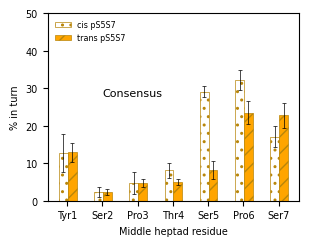

In [120]:
plt.figure()
x = ["Tyr1","Ser2","Pro3","Thr4","Ser5","Pro6","Ser7"]
x_axis = np.arange(len(x))
plt.bar(x_axis - 0.11 ,mid_ctd_phos_pro13_cis_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_phos_pro13_cis_turn_all_final.loc['sem']*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, label = 'cis pS5S7', edgecolor='darkgoldenrod',color = 'orange',fill=None,hatch='..')
plt.bar(x_axis + 0.14,mid_ctd_phos_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_phos_pro13_trans_turn_all_final.loc['sem']*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, label = 'trans pS5S7' , color = 'orange',hatch='//',edgecolor='darkgoldenrod')
plt.xticks(x_axis, x)
plt.legend(loc = "upper left", fontsize = 5.75, frameon = False)
plt.ylabel("% in turn", fontsize = 7)
plt.xlabel("Middle heptad residue", fontsize = 7)
plt.text(1, 30, 'Consensus', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)
plt.ylim(top=50)  
plt.ylim(bottom=0)
#plt.title("Turn Character (phosphorylated)")

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('p_con_turn_cistrans_3.25in.png', dpi=300, bbox_inches='tight')

plt.show()

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


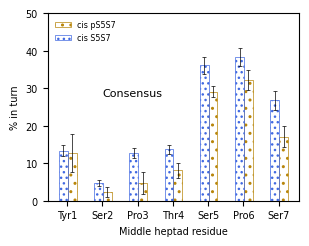

In [121]:
plt.figure()
x = ["Tyr1","Ser2","Pro3","Thr4","Ser5","Pro6","Ser7"]
x_axis = np.arange(len(x))
plt.bar(x_axis + 0.14,mid_ctd_phos_pro13_cis_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_phos_pro13_cis_turn_all_final.loc['sem']*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, label = 'cis pS5S7' ,color='orange',hatch='..',edgecolor='darkgoldenrod',fill=None)
plt.bar(x_axis - 0.11 ,mid_ctd_pro13_cis_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_cis_turn_all_final.loc['sem']*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, label = 'cis S5S7', color='royalblue',fill=None,hatch='...',edgecolor='royalblue')
plt.xticks(x_axis, x)
plt.legend(loc = "upper left", fontsize = 5.75, frameon=False)
plt.ylabel("% in turn", fontsize=7)
plt.xlabel("Middle heptad residue", fontsize=7)
plt.ylim(top=50)  
plt.ylim(bottom=0)
plt.text(1, 30, 'Consensus', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)
#plt.title("CTD Turn Character (Pro13-cis)")

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('p_vs_up_con_turn_cis_3.25in.png', dpi=300, bbox_inches='tight')

plt.show()

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


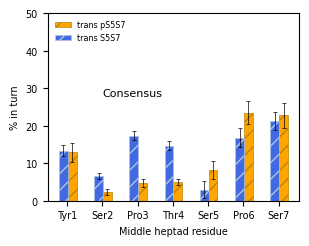

In [122]:
plt.figure()
x = ["Tyr1","Ser2","Pro3","Thr4","Ser5","Pro6","Ser7"]
x_axis = np.arange(len(x))
plt.bar(x_axis + 0.14, mid_ctd_phos_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_phos_pro13_trans_turn_all_final.loc['sem']*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, label = 'trans pS5S7' ,color = 'orange',hatch='//',edgecolor='darkgoldenrod')
plt.bar(x_axis - 0.11 ,mid_ctd_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_cis_turn_all_final.loc['sem']*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, label = 'trans S5S7',color = 'royalblue',hatch='//',edgecolor='lightsteelblue')
plt.xticks(x_axis, x)
plt.legend(loc = "upper left", fontsize = 5.75, frameon=False)
plt.ylabel("% in turn", fontsize=7)
plt.xlabel("Middle heptad residue", fontsize=7)
plt.ylim(top=50)  
plt.ylim(bottom=0)
plt.text(1, 30, 'Consensus', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)
#plt.title("CTD Turn Character (Pro13-trans)")

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('p_vs_up_con_turn_trans_3.25in.png', dpi=300, bbox_inches='tight')

plt.show()

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


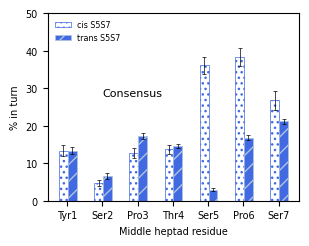

In [123]:
x = ["Tyr1","Ser2","Pro3","Thr4","Ser5","Pro6","Ser7"]

x_axis = np.arange(len(x))

plt.bar(x_axis - 0.11,mid_ctd_pro13_cis_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_cis_turn_all_final.loc['sem']*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, label = 'cis S5S7' , color='royalblue',fill=None,hatch='...',edgecolor='royalblue')
plt.bar(x_axis + 0.14 ,mid_ctd_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_trans_turn_all_final.loc['sem']*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, label = 'trans S5S7', color = 'royalblue',hatch='//',edgecolor='lightsteelblue')
plt.xticks(x_axis, x)
plt.legend(loc = "upper left", fontsize = 5.75, frameon = False)
plt.ylabel("% in turn", fontsize=7)
plt.xlabel("Middle heptad residue", fontsize=7)
plt.ylim(top=50)  
plt.ylim(bottom=0)
plt.text(1, 30, 'Consensus', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)
#plt.title("Turn Character (unphosphorylated)")

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('con_turn_cistrans_3.25in.png', dpi=300, bbox_inches='tight')

plt.show()

# Turn content across entire peptide, unphos vs phos

In [56]:
# Define column names
columns = ['unphos', 'phos']

# Create an empty DataFrame with 2 rows and 5 columns
pro13_turn_percents = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(pro13_turn_percents)

   unphos  phos
0     NaN   NaN
1     NaN   NaN
2     NaN   NaN
3     NaN   NaN
4     NaN   NaN
5     NaN   NaN
6     NaN   NaN
7     NaN   NaN
8     NaN   NaN
9     NaN   NaN


In [57]:
i = 0
for sim in secstruc_cistrans_sim_list:
        
    weights = sim['weights'].sum()

    res_turn_prct = 0
    for col in sim.iloc[:,2:-3]:
        res_turn_prct += ((sim[col] =='T')*sim['weights']).sum()/weights

    mean_turn_prct = res_turn_prct/len(sim.iloc[:,2:-3].columns)
    pro13_turn_percents.at[i, 'unphos'] = mean_turn_prct
    
    i += 1

In [58]:
pro13_turn_percents

,unphos,phos
0,0.106096,NaN
1,0.111788,NaN
2,0.119356,NaN
3,0.105786,NaN
4,0.117139,NaN
5,0.113509,NaN
6,0.107558,NaN
7,0.116333,NaN
8,0.115642,NaN
9,0.110193,NaN


In [59]:
i = 0
for sim in phos_secstruc_cistrans_sim_list:
        
    weights = sim['weights'].sum()

    res_turn_prct = 0
    for col in sim.iloc[:,2:-3]:
        res_turn_prct += ((sim[col] =='T')*sim['weights']).sum()/weights

    mean_turn_prct = res_turn_prct/len(sim.iloc[:,2:-3].columns)
    pro13_turn_percents.at[i, 'phos'] = mean_turn_prct
    
    i += 1

In [60]:
pro13_turn_percents

,unphos,phos
0,0.106096,0.126448
1,0.111788,0.141494
2,0.119356,0.096252
3,0.105786,0.104154
4,0.117139,0.109452
5,0.113509,0.083889
6,0.107558,0.133662
7,0.116333,0.059119
8,0.115642,0.085406
9,0.110193,0.040141


In [61]:
# Calculate the SEM (standard error of the mean)
mean_values = pro13_turn_percents.mean()
sem_values = pro13_turn_percents.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([pro13_turn_percents, pd.DataFrame([mean_values], index=['mean'])])
pro13_turn_percents_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [62]:
pro13_turn_percents_final

,unphos,phos
0,0.106096,0.126448
1,0.111788,0.141494
2,0.119356,0.096252
3,0.105786,0.104154
4,0.117139,0.109452
5,0.113509,0.083889
6,0.107558,0.133662
7,0.116333,0.059119
8,0.115642,0.085406
9,0.110193,0.040141


(0.0, 15.0)

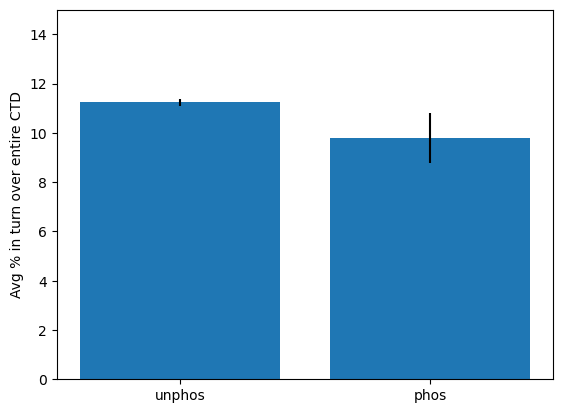

In [63]:
x = ["unphos","phos"]

x_axis = np.arange(len(x))

plt.bar(x_axis,pro13_turn_percents_final.loc['mean']*100, yerr = pro13_turn_percents_final.loc['sem']*100, label = 'Pro6 in Cis' )
#plt.bar(x_axis + 0.14 ,mid_ctd_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_trans_turn_all_final.loc['sem']*100, label = 'Pro6 in Trans', color = 'blue',hatch='//',edgecolor='lightsteelblue')
plt.xticks(x_axis, x)
#plt.legend(loc = "upper left", fontsize = 11, frameon = False)
plt.ylabel("Avg % in turn over entire CTD")
plt.ylim(top=15)  
plt.ylim(bottom=0)


# Cis percentage of just Pro6 looking at all frames where Pro6 is in turn, unphos vs phos

In [84]:
# Define column names
columns = ['unphos', 'phos']

# Create an empty DataFrame with 2 rows and 5 columns
pro13_turn_cis_percents = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(pro13_turn_cis_percents)

   unphos  phos
0     NaN   NaN
1     NaN   NaN
2     NaN   NaN
3     NaN   NaN
4     NaN   NaN
5     NaN   NaN
6     NaN   NaN
7     NaN   NaN
8     NaN   NaN
9     NaN   NaN


## Unphosphorylated

In [85]:
i = 0
for sim in secstruc_cistrans_sim_list:
    
    pro6_turn_true = ((sim['PRO:14'] == 'T')*sim['weights']).sum()
    
    sim_mean = (((sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_turn_true
    pro13_turn_cis_percents.at[i, 'unphos'] = sim_mean

    
    i += 1

In [86]:
pro13_turn_cis_percents

,unphos,phos
0,0.181186,NaN
1,0.277494,NaN
2,0.130583,NaN
3,0.235963,NaN
4,0.363914,NaN
5,0.244515,NaN
6,0.307302,NaN
7,0.192216,NaN
8,0.156050,NaN
9,0.263646,NaN


In [87]:
i = 0
for sim in phos_secstruc_cistrans_sim_list:
    
    pro6_turn_true = ((sim['PRO:14'] == 'T')*sim['weights']).sum()
    
    sim_mean = (((sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_turn_true
    pro13_turn_cis_percents.at[i, 'phos'] = sim_mean

    
    i += 1

In [88]:
pro13_turn_cis_percents

,unphos,phos
0,0.181186,0.268872
1,0.277494,0.259571
2,0.130583,0.162515
3,0.235963,0.242204
4,0.363914,0.233598
5,0.244515,0.000000
6,0.307302,0.795632
7,0.192216,0.000000
8,0.156050,0.000000
9,0.263646,0.000000


In [89]:
# Calculate the SEM (standard error of the mean)
mean_values = pro13_turn_cis_percents.mean()
sem_values = pro13_turn_cis_percents.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([pro13_turn_cis_percents, pd.DataFrame([mean_values], index=['mean'])])
pro13_turn_cis_percents_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [90]:
pro13_turn_cis_percents_final

,unphos,phos
0,0.181186,0.268872
1,0.277494,0.259571
2,0.130583,0.162515
3,0.235963,0.242204
4,0.363914,0.233598
5,0.244515,0.000000
6,0.307302,0.795632
7,0.192216,0.000000
8,0.156050,0.000000
9,0.263646,0.000000


Text(0.5, 1.0, 'Pro6 in Turn')

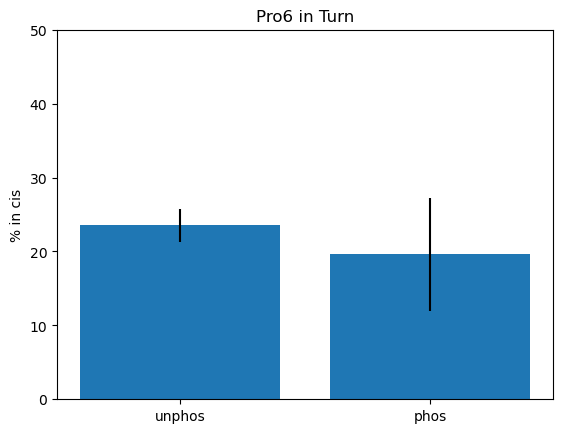

In [91]:
x = ["unphos","phos"]

x_axis = np.arange(len(x))

plt.bar(x_axis,pro13_turn_cis_percents_final.loc['mean']*100, yerr = pro13_turn_cis_percents_final.loc['sem']*100, label = 'Pro6 in Cis' )
#plt.bar(x_axis + 0.14 ,mid_ctd_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_trans_turn_all_final.loc['sem']*100, label = 'Pro6 in Trans', color = 'blue',hatch='//',edgecolor='lightsteelblue')
plt.xticks(x_axis, x)
#plt.legend(loc = "upper left", fontsize = 11, frameon = False)
plt.ylabel("% in cis")
plt.ylim(top=50)  
plt.ylim(bottom=0)
plt.title("Pro6 in Turn")


# Cis percentages

## Unphosphorylated

In [92]:
#ctd_omega_angles.to_csv('con_unphos_omega_angles.csv', index=False)

KeyboardInterrupt: 

In [93]:
cistrans_sim_list = np.array_split(ctd_omega_angles, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [94]:
# Define column names
columns = ['Pro3', 'Pro6', 'Pro10', 'Pro13', 'Pro17', 'Pro20']

# Create an empty DataFrame with 2 rows and 5 columns
cis_percents = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
cis_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(cis_percents)

   Pro3  Pro6  Pro10  Pro13  Pro17  Pro20
0   NaN   NaN    NaN    NaN    NaN    NaN
1   NaN   NaN    NaN    NaN    NaN    NaN
2   NaN   NaN    NaN    NaN    NaN    NaN
3   NaN   NaN    NaN    NaN    NaN    NaN
4   NaN   NaN    NaN    NaN    NaN    NaN
5   NaN   NaN    NaN    NaN    NaN    NaN
6   NaN   NaN    NaN    NaN    NaN    NaN
7   NaN   NaN    NaN    NaN    NaN    NaN
8   NaN   NaN    NaN    NaN    NaN    NaN
9   NaN   NaN    NaN    NaN    NaN    NaN


In [95]:
i = 0
for sim in cistrans_sim_list:

    sim_weight_total = sim['weights'].sum()
    
    sim_mean = (((sim['omega:4'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    cis_percents.at[i, 'Pro3'] = sim_mean
    cis_weights.at[i, 'Pro3'] = sim_weight_total
    sim_mean = (((sim['omega:7'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    cis_percents.at[i, 'Pro6'] = sim_mean
    cis_weights.at[i, 'Pro6'] = sim_weight_total
    sim_mean = (((sim['omega:11'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    cis_percents.at[i, 'Pro10'] = sim_mean
    cis_weights.at[i, 'Pro10'] = sim_weight_total
    sim_mean = (((sim['omega:14'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    cis_percents.at[i, 'Pro13'] = sim_mean
    cis_weights.at[i, 'Pro13'] = sim_weight_total
    sim_mean = (((sim['omega:18'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    cis_percents.at[i, 'Pro17'] = sim_mean
    cis_weights.at[i, 'Pro17'] = sim_weight_total
    sim_mean = (((sim['omega:21'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    cis_percents.at[i, 'Pro20'] = sim_mean
    cis_weights.at[i, 'Pro20'] = sim_weight_total
    
    i += 1

In [96]:
cis_weights

,Pro3,Pro6,Pro10,Pro13,Pro17,Pro20
0,0.119147,0.119147,0.119147,0.119147,0.119147,0.119147
1,0.118070,0.118070,0.118070,0.118070,0.118070,0.118070
2,0.118731,0.118731,0.118731,0.118731,0.118731,0.118731
3,0.118723,0.118723,0.118723,0.118723,0.118723,0.118723
4,0.118852,0.118852,0.118852,0.118852,0.118852,0.118852
5,0.081400,0.081400,0.081400,0.081400,0.081400,0.081400
6,0.081282,0.081282,0.081282,0.081282,0.081282,0.081282
7,0.081110,0.081110,0.081110,0.081110,0.081110,0.081110
8,0.081253,0.081253,0.081253,0.081253,0.081253,0.081253
9,0.081433,0.081433,0.081433,0.081433,0.081433,0.081433


In [97]:
mean_list = []
sem_list = []
for i in range(6):
    print(i)
    mean_list.append(weighted_mean_and_se(cis_percents.iloc[:,i].tolist(), cis_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(cis_percents.iloc[:,i].tolist(), cis_weights.iloc[:,i].tolist())[1])

0
1
2
3
4
5


In [98]:
df_with_mean = pd.concat([cis_percents, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
cis_percents_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [99]:
cis_percents_final

,Pro3,Pro6,Pro10,Pro13,Pro17,Pro20
0,0.101139,0.121870,0.076561,0.085409,0.142737,0.108359
1,0.099007,0.128846,0.117606,0.142529,0.091580,0.129331
2,0.101611,0.121005,0.100273,0.073742,0.109215,0.127927
3,0.102425,0.092792,0.113709,0.133513,0.116054,0.144052
4,0.114614,0.152799,0.121580,0.171699,0.110021,0.124721
5,0.099516,0.086708,0.085982,0.119613,0.146313,0.092216
6,0.090375,0.115581,0.095121,0.168393,0.107796,0.102493
7,0.130838,0.102942,0.174488,0.117300,0.095948,0.104000
8,0.135326,0.130123,0.139448,0.123146,0.090226,0.118725
9,0.073358,0.102411,0.080967,0.133150,0.129546,0.109967


# Phosphorylated

In [100]:
#ctd_phos_omega_angles.to_csv('con_phos_omega_angles.csv', index=False)

In [101]:
phos_cistrans_sim_list = np.array_split(ctd_phos_omega_angles, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [102]:
# Define column names
columns = ['Pro3', 'Pro6', 'Pro10', 'Pro13', 'Pro17', 'Pro20']

# Create an empty DataFrame with 2 rows and 5 columns
phos_cis_percents = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
phos_cis_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_cis_percents)

   Pro3  Pro6  Pro10  Pro13  Pro17  Pro20
0   NaN   NaN    NaN    NaN    NaN    NaN
1   NaN   NaN    NaN    NaN    NaN    NaN
2   NaN   NaN    NaN    NaN    NaN    NaN
3   NaN   NaN    NaN    NaN    NaN    NaN
4   NaN   NaN    NaN    NaN    NaN    NaN
5   NaN   NaN    NaN    NaN    NaN    NaN
6   NaN   NaN    NaN    NaN    NaN    NaN
7   NaN   NaN    NaN    NaN    NaN    NaN
8   NaN   NaN    NaN    NaN    NaN    NaN
9   NaN   NaN    NaN    NaN    NaN    NaN


In [103]:
i = 0
for sim in phos_cistrans_sim_list:

    sim_weight_total = sim['weights'].sum()
    
    sim_mean = (((sim['omega:4'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    phos_cis_percents.at[i, 'Pro3'] = sim_mean
    phos_cis_weights.at[i, 'Pro3'] = sim_weight_total
    sim_mean = (((sim['omega:7'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    phos_cis_percents.at[i, 'Pro6'] = sim_mean
    phos_cis_weights.at[i, 'Pro6'] = sim_weight_total
    sim_mean = (((sim['omega:11'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    phos_cis_percents.at[i, 'Pro10'] = sim_mean
    phos_cis_weights.at[i, 'Pro10'] = sim_weight_total
    sim_mean = (((sim['omega:14'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    phos_cis_percents.at[i, 'Pro13'] = sim_mean
    phos_cis_weights.at[i, 'Pro13'] = sim_weight_total
    sim_mean = (((sim['omega:18'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    phos_cis_percents.at[i, 'Pro17'] = sim_mean
    phos_cis_weights.at[i, 'Pro17'] = sim_weight_total
    sim_mean = (((sim['omega:21'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    phos_cis_percents.at[i, 'Pro20'] = sim_mean
    phos_cis_weights.at[i, 'Pro20'] = sim_weight_total
    
    i += 1

In [104]:
phos_cis_weights

,Pro3,Pro6,Pro10,Pro13,Pro17,Pro20
0,1.997744e-01,1.997744e-01,1.997744e-01,1.997744e-01,1.997744e-01,1.997744e-01
1,1.997902e-01,1.997902e-01,1.997902e-01,1.997902e-01,1.997902e-01,1.997902e-01
2,2.002633e-01,2.002633e-01,2.002633e-01,2.002633e-01,2.002633e-01,2.002633e-01
3,1.999205e-01,1.999205e-01,1.999205e-01,1.999205e-01,1.999205e-01,1.999205e-01
4,1.996144e-01,1.996144e-01,1.996144e-01,1.996144e-01,1.996144e-01,1.996144e-01
5,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25
6,6.371756e-04,6.371756e-04,6.371756e-04,6.371756e-04,6.371756e-04,6.371756e-04
7,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25
8,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25
9,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25,3.302276e-25


In [105]:
mean_list = []
sem_list = []
for i in range(6):
    print(i)
    mean_list.append(weighted_mean_and_se(phos_cis_percents.iloc[:,i].tolist(), phos_cis_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(phos_cis_percents.iloc[:,i].tolist(), phos_cis_weights.iloc[:,i].tolist())[1])

0
1
2
3
4
5


In [106]:
df_with_mean = pd.concat([phos_cis_percents, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
phos_cis_percents_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [107]:
phos_cis_percents_final

,Pro3,Pro6,Pro10,Pro13,Pro17,Pro20
0,0.107438,0.136234,3.569277e-02,0.201839,0.095957,0.162226
1,0.069684,0.122095,2.235434e-01,0.288540,0.088300,0.157881
2,0.075279,0.203916,1.064709e-01,0.140316,0.061723,0.125071
3,0.022247,0.372074,8.933295e-03,0.165641,0.038903,0.119291
4,0.056447,0.349757,2.919398e-02,0.140400,0.038837,0.171116
5,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
6,0.021492,0.154018,1.201768e-01,0.582617,0.069982,0.141875
7,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
8,0.000000,0.000000,6.250000e-07,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000


Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


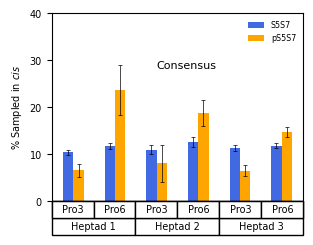

In [118]:
fig = plt.figure

x = ['Pro3','Pro6','Pro3','Pro6','Pro3','Pro6']
h = ['Heptad 1', "Heptad 2", "Heptad 3"]

x_axis = np.arange(len(x))

plt.bar(x_axis - 0.11,cis_percents_final.loc["mean"].apply(lambda f:f*100),0.25,align='center', label = 'S5S7', color = 'royalblue', yerr = cis_percents_final.loc["sem"].apply(lambda f:f*100), error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}) 
plt.bar(x_axis + 0.14,phos_cis_percents_final.loc["mean"].apply(lambda f:f*100),0.25,align='center', label = 'pS5S7', color = 'orange', yerr = phos_cis_percents_final.loc["sem"].apply(lambda f:f*100), error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}) # A bar chart
plt.xticks(x_axis, x, fontsize = 7 )
plt.yticks(fontsize=7)
plt.tick_params(labelbottom=False)
plt.legend(fontsize = 5.75, frameon=False)
#plt.title('Proline $\it{cis}$ Sampled In CTD')
plt.ylabel("% Sampled in $\it{cis}$", fontsize=7)
plt.ylim(0,40)
plt.text(2, 30, 'Consensus', fontsize=8, verticalalignment='top')
# this is dumb and no one should do it like this but I have to because SOMEONE didn't make this table its own figure :p
tabl = plt.table(cellText=[x], loc="bottom", cellLoc='center')
tabl2 = plt.table(cellText=[["","",""], h], loc="bottom", cellLoc='center')
tabl.set_fontsize(7)
tabl2.set_fontsize(7)

tabl.scale(1,2)
tabl.zorder = 2
tabl2.scale(1,2)
tabl2.zorder = 1

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('cis_percentage_con.png', dpi=300, bbox_inches='tight')

plt.show()

In [39]:
# --- 1. Define Setup and Placeholder Data (Replace with your actual data) ---
group1_data = cis_percents
group2_data = phos_cis_percents

# Weights are now DataFrames (10 rows x 6 columns)
# Note: For the permutation test to work, the weights in each column must correspond to the data in that column.
group1_weights = cis_weights
group2_weights = phos_cis_weights

# --- 2. Combine Data and Weights ---
both_groups = pd.concat([group1_data, group2_data], ignore_index=True) # 20x6 DataFrame
both_weights = pd.concat([group1_weights, group2_weights], ignore_index=True) # 20x6 DataFrame

# Total number of simulations (i.e., rows) in the original groups
num_sims = len(group1_data) # This will be 10

# Normalize the combined weights (column-wise)
# Each weight column is normalized separately to sum to 1.
both_p = both_weights / both_weights.sum(axis=0)

# --- 3. Calculate the Observed Weighted Difference (per column) ---
original_diff_means = {}
for col in both_groups.columns:
    # Use the weights specific to the current column
    group1_w_mean = np.average(group1_data[col], weights=group1_weights[col])
    group2_w_mean = np.average(group2_data[col], weights=group2_weights[col])

    if group2_w_mean > group1_w_mean:
        group2_greater = True
        original_diff_means[col] = group2_w_mean - group1_w_mean
    else:
        group2_greater = False
        original_diff_means[col] = group1_w_mean - group2_w_mean

# --- 4. Perform the Permutation Test (per column) ---
numsample = 10000
results_p_value = {}

# Iterate over each column (the test is independent for each column)
for col in both_groups.columns:
    # Extract the data and the weights for the current column as arrays
    both_col_data = both_groups[col].values
    both_col_weights = both_p[col].values
    original_diff = original_diff_means[col]
    
    diff_samples_col = np.zeros(numsample)
    diff_samples_larger_col = np.zeros(numsample, dtype=int)
    
    # Run the permutation loop
    for sample in range(numsample):
        # Randomize data and weights using the same permutation 'p'
        p = np.random.permutation(len(both_groups))
        random_both_data = both_col_data[p]
        random_weights = both_col_weights[p]
        
        # Calculate the weighted mean difference for the permuted split
        # Group A: First 10 rows (0 to num_sims)
        group_A_w_mean = np.average(random_both_data[0:num_sims], weights=random_weights[0:num_sims])
        # Group B: Second 10 rows (num_sims to 2*num_sims)
        group_B_w_mean = np.average(random_both_data[num_sims:num_sims * 2], weights=random_weights[num_sims:num_sims * 2])

        if group2_greater == True:
            diff_samples_col[sample] = group_B_w_mean - group_A_w_mean
        else:
            diff_samples_col[sample] = group_A_w_mean - group_B_w_mean
        
        # Check if the permuted difference is as extreme or more extreme
        if diff_samples_col[sample] >= original_diff:
            diff_samples_larger_col[sample] = 1
            
    # Calculate the p-value
    p_value = (1 + np.sum(diff_samples_larger_col)) / (numsample + 1)
    results_p_value[col] = p_value

# --- 5. Print Results ---
print("### Permutation Test Results (Weighted Mean Difference) ###")
print(f"Number of Permutations: {numsample}\n")

for col, p_value in results_p_value.items():
    print(f"**{col}:**")
    print(f"  Observed Weighted Difference: {original_diff_means[col]:.4f}")
    print(f"  Calculated P-value: {p_value:.4f}")

### Permutation Test Results (Weighted Mean Difference) ###
Number of Permutations: 10000

**Pro3:**
  Observed Weighted Difference: 0.0384
  Calculated P-value: 0.0061
**Pro6:**
  Observed Weighted Difference: 0.1198
  Calculated P-value: 0.0040
**Pro10:**
  Observed Weighted Difference: 0.0289
  Calculated P-value: 0.2610
**Pro13:**
  Observed Weighted Difference: 0.0618
  Calculated P-value: 0.0127
**Pro17:**
  Observed Weighted Difference: 0.0492
  Calculated P-value: 0.0008
**Pro20:**
  Observed Weighted Difference: 0.0289
  Calculated P-value: 0.0151


# Isomerization frequency for one representative simulation

In [95]:
n_frames = len(cistrans_sim_list[0])
#x_list = np.arange(0, n_frames)
x_list = np.linspace(0, n_frames/1e4, n_frames)
data = df_360['omega:14'].head(n_frames)

Current dimensions: 6.4 x 4.8 inches
New dimensions: 6.5 x 4.874999999999999 inches


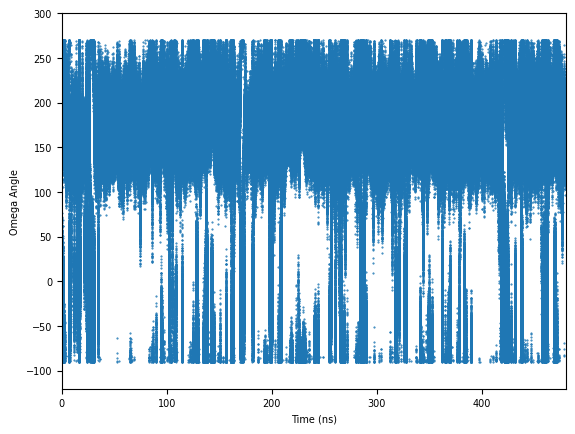

In [103]:
plt.figure()
plt.plot(x_list, data, '.', ls='none', markersize=1)
plt.xlim(0, n_frames/1e4)
plt.ylim(-120, 300)
plt.ylabel("Omega Angle", fontsize=7)
plt.xlabel("Time (ns)", fontsize=7)
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 6.5

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('ismoerization_ex.png', dpi=300, bbox_inches='tight')

plt.show()

In [90]:
df_360.head()

,#Frame,omega:3,omega:4,omega:5,omega:6,omega:7,omega:8,omega:9,omega:10,omega:11,...,omega:13,omega:14,omega:15,omega:16,omega:17,omega:18,omega:19,omega:20,omega:21,omega:22
0,1,169.0,170.0,159.0,177.0,152.0,203.0,168.0,176.0,179.0,...,181.0,-18.0,166.0,171.0,147.0,219.0,182.0,210.0,-76.0,202.0
1,2,170.0,170.0,161.0,181.0,152.0,197.0,144.0,185.0,177.0,...,184.0,-6.0,173.0,186.0,160.0,229.0,189.0,214.0,-43.0,182.0
2,3,161.0,164.0,155.0,162.0,165.0,212.0,151.0,195.0,184.0,...,194.0,-2.0,168.0,161.0,145.0,235.0,192.0,226.0,-29.0,177.0
3,4,166.0,160.0,153.0,183.0,156.0,206.0,142.0,188.0,182.0,...,201.0,-9.0,166.0,176.0,134.0,220.0,180.0,221.0,-43.0,209.0
4,5,169.0,167.0,147.0,170.0,172.0,195.0,150.0,199.0,184.0,...,186.0,0.0,161.0,176.0,153.0,231.0,182.0,214.0,-41.0,198.0


In [92]:
# Count transitions
df = cistrans_sim_list[0]

# Forward fill all "neither"s with the last valid transition
# Replace 'neither' with NaN first. This is crucial because ffill() works on NaNs.
df['omega:14'] = df['omega:14'].replace('neither', np.nan)

# Now, forward fill the NaN values
df['omega:14'] = df['omega:14'].ffill()


cis_to_trans = ((df['omega:14'].shift() == 'cis') & (df['omega:14'] == 'trans')).sum()
trans_to_cis = ((df['omega:14'].shift() == 'trans') & (df['omega:14'] == 'cis')).sum()

print(f"Cis to Trans transitions: {cis_to_trans}")
print(f"Trans to Cis transitions: {trans_to_cis}")

Cis to Trans transitions: 2565
Trans to Cis transitions: 2564


In [93]:
# Calculate number of flips/ns
((cis_to_trans + trans_to_cis)/(n_frames/1e4))

10.685416666666667